In [ ]:
# salloc -t 60 -p short -J Interase_DIL --ntasks=1 --cpus-per-task=4 --mem=64G srun --pty bash

module purge
module load cuda/12.0
module load anaconda/2024.10-1
source "$(conda info --base)/etc/profile.d/conda.sh"
conda activate torch_gpu

In [1]:
# python stage4_eval.py --list sbc_lists/pathA.list --out eval_sbc_out/pathA --dlogp 10 --n-corner 4 --filtered-only
# python stage4_eval.py --list sbc_lists/cnn_vmim_nojit_n1.list --out sbc_out/pathB --dlogp 10 --n-corner 4 --filtered-only
# python stage4_eval.py --list sbc_lists/baseline.list --out eval_sbc_out/reference --dlogp 10 --n-corner 4 --filtered-only

## Setup

In [10]:
import os, subprocess, sys
from pathlib import Path
import numpy as np, yaml
from IPython.display import Image, display

# notebooks/ -> repo root, so tools/ and configs/ resolve
REPO = Path.cwd().resolve()
if REPO.name == "notebook":
    REPO = REPO.parent
os.chdir(REPO)
sys.path.insert(0, str(REPO))
from sbi.seeding import resolve_arm_name      # torch-free, safe on a login node

FIGS = REPO / "notebook" / "figs"
FIGS.mkdir(parents=True, exist_ok=True)
print("repo:", REPO)

repo: /obs/ddehiwalage-don/21cm/sbi_project_FIN


In [11]:
import re

def sh(cmd):
    print("$", cmd, flush=True)
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.stdout.strip(): print(r.stdout.strip()[-2500:])
    if r.returncode:     print("[FAILED]", r.stderr.strip()[-2500:])
    return r.returncode == 0

def show(p, width=1100):
    p = str(p)
    if p.endswith(".pdf"):                     # rasterise for inline display
        prev = p[:-4] + "_preview"
        if os.system(f'pdftoppm -png -r 150 -singlefile "{p}" "{prev}" 2>/dev/null') == 0:
            p = prev + ".png"
    display(Image(p, width=width)) if os.path.exists(p) else print("missing:", p)

def arm(cfg_path, cseed=None):
    """Paths for ONE compressor seed.

    cseed=None  -> whatever the yaml resolves to (resolve_arm_name honours
                   compressor.tag_arm_with_seed).
    cseed=<N>   -> {arm_name}_s<N>, which is what submit_nle_grid.sh produces.
                   The launcher overrides compressor.init_seed on the COMMAND
                   LINE, so the yaml never knows about the grid and the
                   notebook has to name the member explicitly.
    """
    c  = yaml.safe_load(open(cfg_path))
    cc = c.get("compressor", {}) or {}
    nc = c.get("nle", {}) or {}
    name = f'{c["arm_name"]}_s{cseed}' if cseed is not None else resolve_arm_name(c)
    root = Path(c["scratch_root"]) / name
    # scope resolution, mirroring stage2_nle.py exactly:
    #   t_scaling  >  standardize  >  default "standard"
    mode = str(nc.get("t_scaling") or
               ("standard" if nc.get("standardize", True) else "raw")).lower()
    return dict(cfg=cfg_path, type=c.get("arm_type", "cnn"), root=root, name=name,
                nle=root / "nle", summ=root / "summaries", chains=root / "chains",
                scope="standard_t" if mode == "standard" else "raw_t",
                t_scaling=mode, cseed=cseed,
                dequant=cc.get("dequant", {}) or {},
                sigma_floor=float(cc.get("sigma_floor", 1e-2)),
                aux_only=bool(cc.get("aux_only", False)),
                nsplit=int(nc.get("nsplit", 10)),
                epochs=int(cc.get("epochs", 0)))

def nle_dir(a, fam, nseed=None):
    """stage2 writes nle/<scope>/<fam>/ , or .../seed_<N>/ when nle.seed_subdir."""
    d = a["nle"] / a["scope"] / fam
    return d / f"seed_{nseed}" if nseed is not None else d

def chains_dir(a, fam, nseed=None):
    """stage3 writes chains/<scope>_<fam>[_seed_<N>]/.

    The _seed_<N> suffix needs the stage3_mcmc.py tag patch; without it every
    NLE seed writes the SAME filenames into chains/<scope>_<fam>/ and silently
    overwrites the previous one. Fall back so the notebook still reports.
    """
    seeded = a["chains"] / f"{a['scope']}_{fam}_seed_{nseed}"
    plain  = a["chains"] / f"{a['scope']}_{fam}"
    if nseed is None:
        return plain
    return seeded if seeded.is_dir() else plain

def found_cseeds(cfg_path):
    """Compressor seeds actually on disk, for when you don't want to list them."""
    c = yaml.safe_load(open(cfg_path))
    r = Path(c["scratch_root"]) / c["arm_name"]
    out = []
    for p in sorted(r.parent.glob(r.name + "_s*")):
        m = re.search(r"_s(\d+)$", p.name)
        if m and p.is_dir(): out.append(int(m.group(1)))
    return out

def found_nseeds(a, fam):
    base = a["nle"] / a["scope"] / fam
    if not base.is_dir(): return []
    out = []
    for p in base.glob("seed_*"):
        m = re.search(r"seed_(\d+)$", p.name)
        if m and p.is_dir(): out.append(int(m.group(1)))
    return sorted(out)

In [3]:
!python check_status.py configs/vmim_/arm_cnn_vmim_n1_jit_0.1.yaml --auto-seeds --families nsf



cnn_vmim_up/jitter/seed_n1_s43   [cnn, scope=standard_t]
  stage1  MISSING  no summaries/t.npy
  nsf         stage2 MISSING  not started
              stage3 MISSING  not started

0/1 cells complete -- INCOMPLETE


## Groups

Edit this cell only. `ONLY` restricts every section below to one group.

In [12]:
NAMES = ["Fx", "tau", "rHS", "Mmin"]     # theta order, NOT latent dims

# cseeds -> compressor init_seeds, one ARM TREE each: {arm_name}_s<cs>
# nseeds -> NLE init_seeds, which live INSIDE one arm tree:
#             nle/<scope>/<fam>/seed_<ns>/  and  chains/<scope>_<fam>_seed_<ns>/
# Use None (or omit) for the un-seeded layout of the older runs.
GROUPS = {
    #"baseline": dict(families=["gmm"], arms={...}),
    #"path A":   dict(families=["gmm","nsf"], arms={...}),

    #"path B legacy": dict(
    #    families=["nsf"],
    #    arms={"cnn vmim seeds": "configs/vmim_/arm_cnn_vmim_n1_jit_0.1.yaml",          
    #          }),

    "path B seeds": dict(
        families=["nsf"],
        cseeds=[43, 44, 45],          # or: found_cseeds("configs/.../x.yaml")
        nseeds=[42, 43],
        arms={"cnn vmim seeds": "configs/vmim_/arm_cnn_vmim_n1_jit_0.1.yaml"}),
}

ONLY = "path B seeds"      # None = all groups

def expand(v):
    """One entry per (arm label x compressor seed).

    NLE seeds are NOT expanded here: they live inside a single compressor arm's
    nle/ and chains/ trees, so sections 1-3 (stage-1 diagnostics) must not
    multiply by them. Section 4 and 5 loop over v["nseeds"] instead.
    """
    out = {}
    for label, p in v["arms"].items():
        for cs in (v.get("cseeds") or [None]):
            out[label if cs is None else f"{label} s{cs}"] = arm(p, cseed=cs)
    return out

G = {g: {**v, "nseeds": v.get("nseeds") or [None], "arms": expand(v)}
     for g, v in GROUPS.items() if ONLY is None or g == ONLY}

for g, v in G.items():
    print(f"=== {g}   families={v['families']}   nle seeds={v['nseeds']}")
    for k, a in v["arms"].items():
        print(f"  {k:<14} {a['type']:<4} {a['scope']:<11} "
              f"nle={int(a['nle'].is_dir())} summ={int((a['summ']/'t.npy').exists())}"
              f"  {a['root']}")

=== path B seeds   families=['nsf']   nle seeds=[42, 43]
  cnn vmim seeds s43 cnn  standard_t  nle=1 summ=0  /gscratch/ddehiwalage-don/sbi/cnn_vmim_up/jitter/seed_n1_s43
  cnn vmim seeds s44 cnn  standard_t  nle=1 summ=0  /gscratch/ddehiwalage-don/sbi/cnn_vmim_up/jitter/seed_n1_s44
  cnn vmim seeds s45 cnn  standard_t  nle=1 summ=0  /gscratch/ddehiwalage-don/sbi/cnn_vmim_up/jitter/seed_n1_s45


## 1. Progress

Read straight from the `.npy` logs, so this works mid-run.

`rf_r2_history.npy` is `[epoch, phase, aux_coef, R2 x P]`; the R2s are always the
last P columns and are indexed by **parameter**, not by latent dimension (the
trainer prints `t0..t3`, which is a misnomer). The **best** row is the one whose
checkpoint gets exported, so that is the line to watch.

In [13]:
for g, v in G.items():
    print(f"===== {g} =====")
    for k, a in v["arms"].items():
        if a["type"] == "raw":
            print(f"  {k:<10} raw arm -- no compressor to report")
            continue
        f = a["nle"] / "rf_r2_history.npy"
        if not f.exists():
            print(f"  {k:<10} no rf_r2_history yet"); continue
        h  = np.load(f)
        r2 = h[:, -len(NAMES):]
        b  = int(np.argmax(r2.mean(1)))
        print(f"  {k:<10} epoch {int(h[-1,0]):>3}/{a['epochs']}  "
              f"last R2 {np.round(r2[-1],3)} mean {r2[-1].mean():.3f}")
        print(f"  {'':<10} best @{int(h[b,0]):>3}   R2 {np.round(r2[b],3)} "
              f"mean {r2[b].mean():.3f}   <- exported checkpoint")
        l = a["nle"] / "loss_history.npy"
        if l.exists():
            ll = np.load(l)
            print(f"  {'':<10} vmim loss  train {ll[-1,1]:.4f}  val {ll[-1,2]:.4f}")
    print()

===== path B seeds =====
  cnn vmim seeds s43 epoch 150/200  last R2 [0.968 0.916 0.748 0.936] mean 0.892
             best @100   R2 [0.971 0.934 0.803 0.953] mean 0.915   <- exported checkpoint
             vmim loss  train -9.6293  val -10.6533
  cnn vmim seeds s44 epoch 150/200  last R2 [0.967 0.952 0.835 0.962] mean 0.929
             best @120   R2 [0.981 0.955 0.853 0.96 ] mean 0.937   <- exported checkpoint
             vmim loss  train -9.8563  val -10.6442
  cnn vmim seeds s45 epoch 150/200  last R2 [0.97  0.917 0.808 0.969] mean 0.916
             best @140   R2 [0.975 0.904 0.871 0.963] mean 0.928   <- exported checkpoint
             vmim loss  train -8.9163  val -9.5881



## 2. Compressor

One figure per group, arms overlaid -- only then are the VMIM losses on a
commensurable scale. Skipped for the baseline, which has no compressor.

The sigma panel carries three reference levels: the prior sigma
`1/sqrt(12) = 0.289` (the head learned nothing about that parameter), the
dequant floor `half/sqrt(3)` (it cannot resolve below the jitter width), and
`sigma_floor` (sitting on it means saturated / overconfident).

===== path B seeds =====
$ python tools/plot_training_compressor.py "cnn vmim seeds s43"=/gscratch/ddehiwalage-don/sbi/cnn_vmim_up/jitter/seed_n1_s43/nle "cnn vmim seeds s44"=/gscratch/ddehiwalage-don/sbi/cnn_vmim_up/jitter/seed_n1_s44/nle "cnn vmim seeds s45"=/gscratch/ddehiwalage-don/sbi/cnn_vmim_up/jitter/seed_n1_s45/nle --names Fx tau rHS Mmin --dequant 2:0.1 2:0.1 2:0.1 --sigma-floor 0.01 --out /obs/ddehiwalage-don/21cm/sbi_project_FIN/notebook/figs/compressor_path_B_seeds.pdf --png
wrote /obs/ddehiwalage-don/21cm/sbi_project_FIN/notebook/figs/compressor_path_B_seeds.pdf
wrote /obs/ddehiwalage-don/21cm/sbi_project_FIN/notebook/figs/compressor_path_B_seeds.png

best RF-R2 (per parameter):
  arm                        Fx       tau       rHS      Mmin
  cnn vmim seeds s43      0.978     0.937     0.803     0.966
  cnn vmim seeds s44      0.987     0.960     0.853     0.973
  cnn vmim seeds s45      0.980     0.919     0.871     0.977

final RF-R2 (per parameter):
  arm               

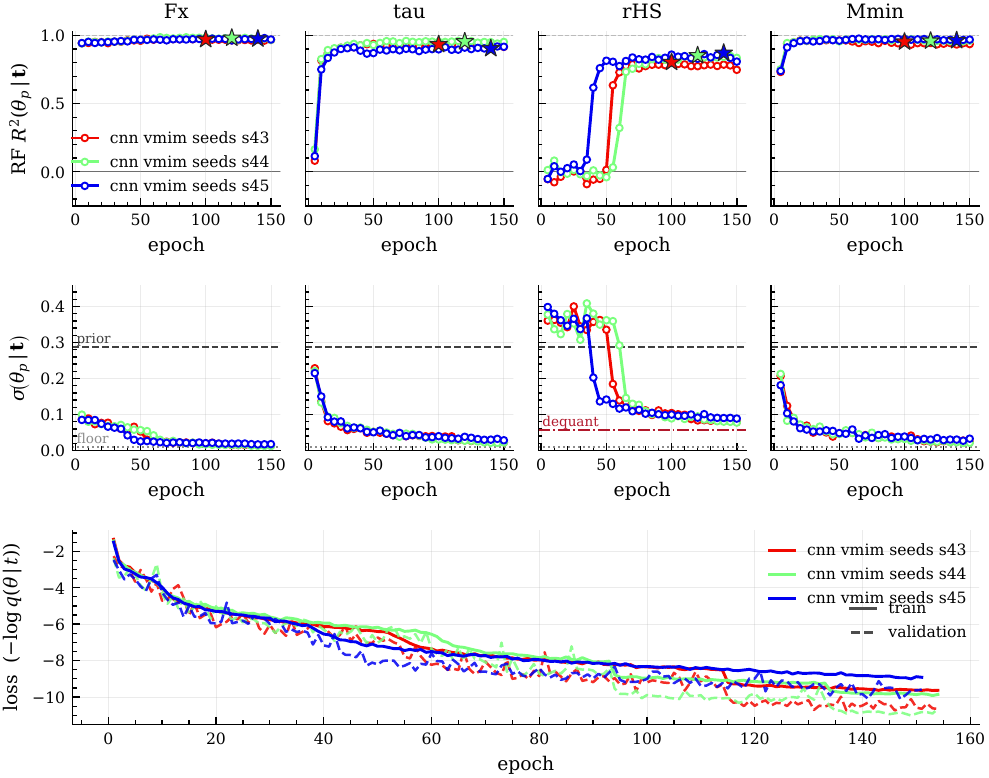

In [14]:
for g, v in G.items():
    arms = {k: a for k, a in v["arms"].items()
            if a["type"] != "raw" and (a["nle"] / "rf_r2_history.npy").exists()}
    if not arms:
        why = ("raw arm -- no compressor"
               if all(a["type"] == "raw" for a in v["arms"].values())
               else "stage 1 has not written rf_r2_history yet")
        print(f"[{g}] nothing to plot ({why})")
        continue
    deq = " ".join(f"{i}:{s['half']}" for a in arms.values()
                   for i, s in a["dequant"].items())
    args = " ".join(f'"{k}"={a["nle"]}' for k, a in arms.items())
    out  = FIGS / f"compressor_{g.replace(' ', '_')}.pdf"
    print(f"===== {g} =====")
    sh(f'python tools/plot_training_compressor.py {args} '
       f'--names {" ".join(NAMES)} '
       + (f'--dequant {deq} ' if deq else "")
       + f'--sigma-floor {list(arms.values())[0]["sigma_floor"]} --out {out} --png')
    show(out)

## 4. NLE

One row per config, one column per t-scaling scope found. Solid = train,
dashed = val, grey dotted = the phase-1 -> phase-2 learning-rate drop.

This is the only section the baseline participates in.

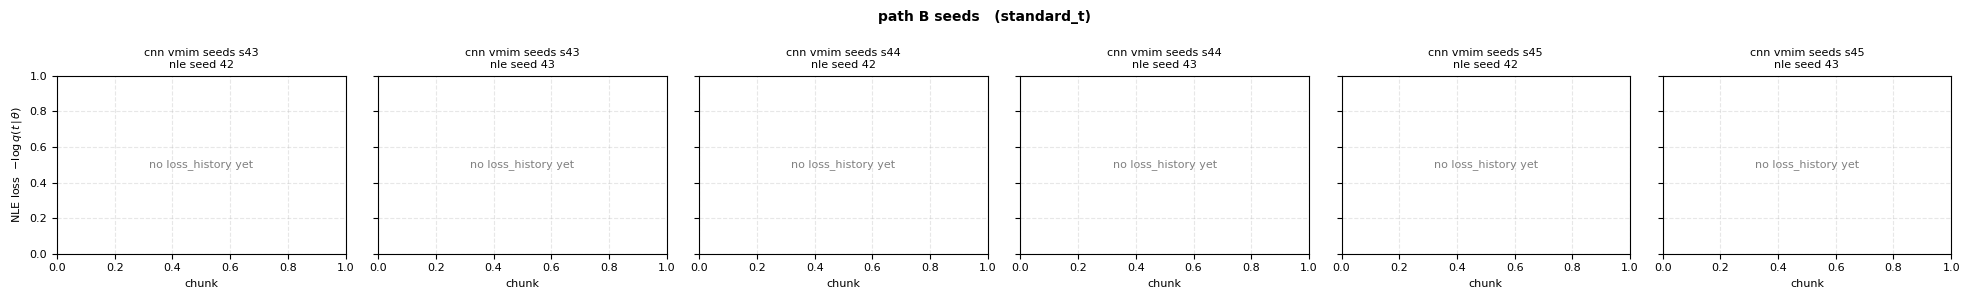

In [6]:
import matplotlib.pyplot as plt

FAM_C = {"gmm": "tab:blue", "nsf": "tab:red", "maf": "tab:green", "made": "tab:orange"}

def nle_loss(a, fam, nseed=None):
    """(chunks, train, val) from loss_history.npy, or None."""
    f = nle_dir(a, fam, nseed) / "loss_history.npy"
    if not f.exists():
        return None
    h = np.load(f)
    if h.ndim == 1:
        h = h[None, :]
    return h[:, 0], h[:, 1], h[:, 2]

for g, v in G.items():
    # one panel per (compressor arm x NLE seed)
    cells = [(k, a, ns) for k, a in v["arms"].items() for ns in v["nseeds"]]
    n = len(cells)
    fig, axes = plt.subplots(1, n, figsize=(3.3 * n, 3.0), sharey=True, squeeze=False)
    axes = axes[0]
    any_data = False

    for ax, (k, a, ns) in zip(axes, cells):
        drew = False
        for fam in v["families"]:
            d = nle_loss(a, fam, ns)
            if d is None:
                continue
            x, tr, va = d
            c = FAM_C.get(fam, "grey")
            ax.plot(x, tr, "-",  color=c, lw=1.6, label=f"{fam} train")
            ax.plot(x, va, "--", color=c, lw=1.2, alpha=0.75, label=f"{fam} val")
            b = int(np.argmin(va))
            ax.plot(x[b], va[b], "o", color=c, ms=5, mfc="white", mew=1.4)
            ax.annotate(f"{va[b]:.3f}", (x[b], va[b]), textcoords="offset points",
                        xytext=(3, -11), fontsize=7, color=c)
            any_data = drew = True
            # phase-1 -> phase-2 LR drop at chunk nsplit; phase-2 chunks are
            # TWICE as wide, so the x axis is chunks, not equal work
            if len(x) > a["nsplit"]:
                ax.axvline(a["nsplit"] + 0.5, color="grey", ls=":", lw=0.9, alpha=0.7)

        ttl = k if ns is None else f"{k}\nnle seed {ns}"
        ax.set_title(ttl, fontsize=8)
        ax.set_xlabel("chunk", fontsize=8)
        ax.grid(True, ls="--", alpha=0.3)
        ax.tick_params(labelsize=8)
        if not drew:
            ax.text(0.5, 0.5, "no loss_history yet", ha="center", va="center",
                    transform=ax.transAxes, color="grey", fontsize=8)

    axes[0].set_ylabel("NLE loss  $-\\log q(t\\,|\\,\\theta)$", fontsize=8)
    if any_data:
        axes[-1].legend(fontsize=7, framealpha=0.9)
    fig.suptitle(f"{g}   ({v['arms'] and list(v['arms'].values())[0]['scope']})",
                 fontsize=10, fontweight="semibold")
    fig.tight_layout()
    plt.show()

In [ ]:
# best val NLL per (arm x nle seed x family), straight from the loss logs.
# NOTE raw_t and standard_t NLLs live in DIFFERENT coordinate systems and are
# NOT comparable as numbers -- compare via SBC/GV in stage 4, not by this loss.
print(f"{'group':<15} {'arm':<15} {'nle':<5} {'fam':<4} {'chunks':>7} "
      f"{'train':>9} {'val':>9} {'best val':>9}")
best = {}
for g, v in G.items():
    for k, a in v["arms"].items():
        for ns in v["nseeds"]:
            for fam in v["families"]:
                f = nle_dir(a, fam, ns) / "loss_history.npy"
                lab = "-" if ns is None else str(ns)
                if not f.exists():
                    print(f"{g:<15} {k:<15} {lab:<5} {fam:<4} {'-':>7}"
                          f"{'not started':>29}")
                    continue
                h = np.load(f)
                exp = a["nsplit"] + max(1, a["nsplit"] // 2)
                flag = "" if len(h) >= exp else f"  <- only {len(h)}/{exp}, incomplete"
                print(f"{g:<15} {k:<15} {lab:<5} {fam:<4} {len(h):>3}/{exp:<3} "
                      f"{h[-1,1]:>9.4f} {h[-1,2]:>9.4f} {h[:,2].min():>9.4f}{flag}")
                best.setdefault((g, fam), []).append(h[:, 2].min())

# spread across the ensemble -- the number that says whether a difference is real
for (g, fam), vals in best.items():
    if len(vals) > 1:
        vals = np.array(vals)
        print(f"\n{g} / {fam}:  n={len(vals)}  best-val mean {vals.mean():.4f}  "
              f"sd {vals.std(ddof=1):.4f}  ({100*vals.std(ddof=1)/abs(vals.mean()):.1f}%)")

## 3. Latent space

Needs `summaries/t.npy`. For path B that means the export array **and** the merge
must have finished; for path A it lands with stage 1.

Skipped for the baseline: its `t.npy` is a verbatim copy of the hand-crafted
summaries, not a learned latent, so "latent SNR" would be a category error.

`--grid-param rHS` draws the grid-band figure -- the direct picture of what the
dequantisation jitter does to the quantised parameter.

In [ ]:
for g, v in G.items():
    arms = {k: a for k, a in v["arms"].items() if a["type"] != "raw"}
    ready = {k: a for k, a in arms.items() if (a["summ"] / "t.npy").exists()}
    print(f"===== {g} =====")
    if not arms:
        print("  raw arm -- t.npy is the hand-crafted summaries, not a latent"); continue
    if not ready:
        print("  no summaries/t.npy yet.")
        for k, a in arms.items():
            if a["type"] == "cnn":      # only path B shards its export
                n = len(list(a["summ"].glob("part_*"))) if a["summ"].is_dir() else 0
                print(f"    {k:<10} {n} part_* shard dirs "
                      f"(merge writes t.npy once all are present)")
            else:
                print(f"    {k:<10} export is inline in stage 1 -- still running?")
        continue
    args = " ".join(f'"{k}"={a["summ"]}' for k, a in ready.items())
    pre  = FIGS / f"latent_{g.replace(' ', '_')}"
    sh(f'python tools/plot_latent_island.py {args} --names {" ".join(NAMES)} '
       f'--out {pre} --max-sims 1200 --corner --grid-param rHS')
    for suf in ("_snr.png", "_pca.png", "_corr.png", "_gridband.png"):
        show(str(pre) + suf)

## 5. Chains

`used == unique sims` is the invariant stage 4 depends on. `list_chains` globs
every `*.dat` in a family directory and `chain_sim` reads the sim id out of the
filename, so a stale run left behind under different `row`/`noise` tags is
counted **twice** -- doubling `used` and silently corrupting the calibration.

Path B re-exports change the row order (shards are concatenated noise-block
major, so row indices depend on NSHARD), which is why `--overwrite` is not
enough there: delete the family directory instead.

In [ ]:
PAT = re.compile(r"_sim(\d+)_")
print(f"{'group':<15} {'arm':<15} {'nle':<5} {'chains dir':<32} {'files':>6} {'sims':>6}  status")
for g, v in G.items():
    for k, a in v["arms"].items():
        for ns in v["nseeds"]:
            for fam in v["families"]:
                d = chains_dir(a, fam, ns)
                lab = "-" if ns is None else str(ns)
                if not d.is_dir():
                    print(f"{g:<15} {k:<15} {lab:<5} {d.name:<32} {'-':>6} {'-':>6}"
                          f"  not started")
                    continue
                # an unpatched stage3 writes every NLE seed into the SAME
                # <scope>_<fam> dir, so seeds silently overwrite each other
                if ns is not None and not d.name.endswith(f"seed_{ns}"):
                    print(f"{g:<15} {k:<15} {lab:<5} {d.name:<32} {'?':>6} {'?':>6}"
                          f"  NOT SEED-SEPARATED -- patch stage3_mcmc.py")
                    continue
                files = sorted(d.glob("*.dat"))
                sims  = {int(m.group(1)) for f in files if (m := PAT.search(f.name))}
                ok = "OK" if len(files) == len(sims) else "DUPLICATES -- rm -rf this dir"
                print(f"{g:<15} {k:<15} {lab:<5} {d.name:<32} "
                      f"{len(files):>6} {len(sims):>6}  {ok}")